# Matplotlib 

* Matplotlib is a Python library for data visualization .
* It features advanced features for creating charts, including animated and interactive ones
* It offers the possibility to customize graphs and export them in various formats.
* It is open-source and freely accessible (BSD, free license).

## Motivation

* Used to create quality graphics for reports and publications.
* Interactivity and customization are extensive.
* Integrated with different graphical interfaces or work environments, such as Jupyter Notebooks .
* Other widely used graphics libraries, such as Seaborn , are based on Matplotlib.

## Modes

In Matplotlib there are 2 fundamental ways to build graphs, i.e., 2 fundamental ways to manage the functions that allow us to build or modify graphs as we like:
* Object-Oriented mode
* pyplot interface mode

<img src='../../docs/matplotlib_modes.png'>


In [3]:
import matplotlib.pyplot as plt
import math
import pandas as pd
import numpy as np

# Disegno Curve

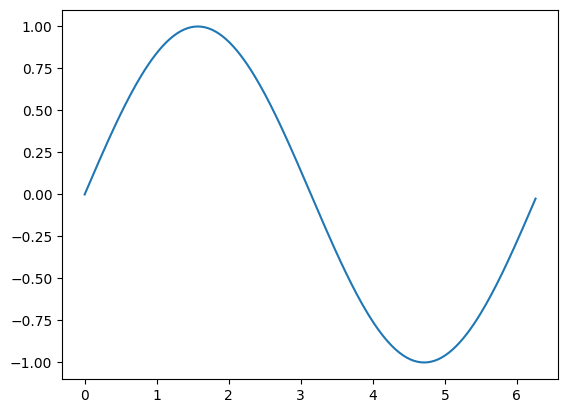

In [4]:
n = 256
x,y = [], []
for i in range(n):
    x.append(2*math.pi*i/n)
    y.append(math.sin(x[-1]))
plt.plot(x,y)
plt.show()
    

In [5]:
df = pd.DataFrame({'x':x,'y':y})
df.head(2)

,x,y
0,0.000000,0.000000
1,0.024544,0.024541


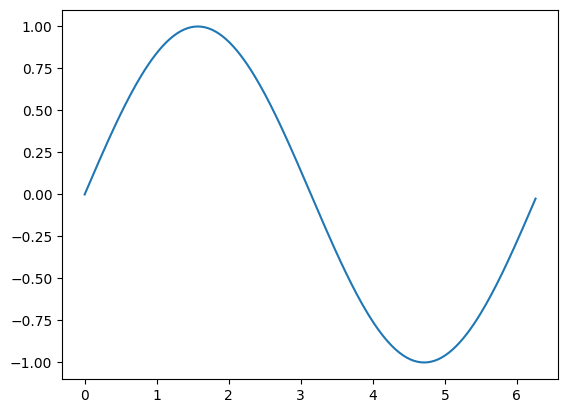

In [6]:
plt.plot(df['x'],df['y'])
plt.show()

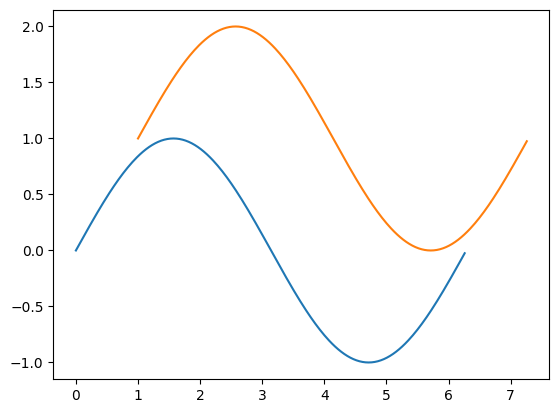

In [7]:
# disegna curve multiple su uno stesso grafico

df['x2'] = df['x'] + 1
df['y2'] = df['y'] + 1

plt.plot(df['x'],df['y'])
plt.plot(df['x2'],df['y2'])
plt.show()

In [8]:
df

,x,y,x2,y2
0,0.000000,0.000000,1.000000,1.000000
1,0.024544,0.024541,1.024544,1.024541
2,0.049087,0.049068,1.049087,1.049068
3,0.073631,0.073565,1.073631,1.073565
4,0.098175,0.098017,1.098175,1.098017
...,...,...,...,...
251,6.160467,-0.122411,7.160467,0.877589
252,6.185011,-0.098017,7.185011,0.901983
253,6.209554,-0.073565,7.209554,0.926435
254,6.234098,-0.049068,7.234098,0.950932


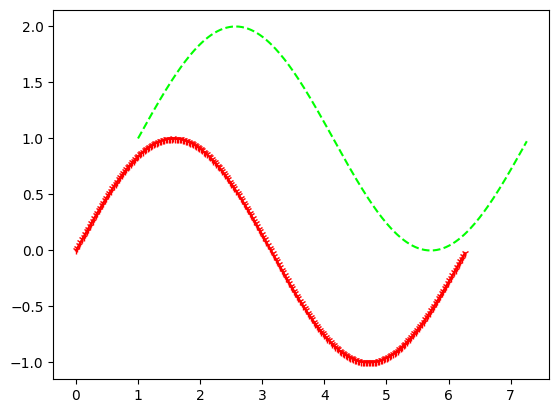

In [6]:
# customizzare i grafici
plt.plot(df['x'],df['y'],c='#ff0000',marker='1')
plt.plot(df['x2'],df['y2'],c='#00ff00',linestyle='--')
plt.show()

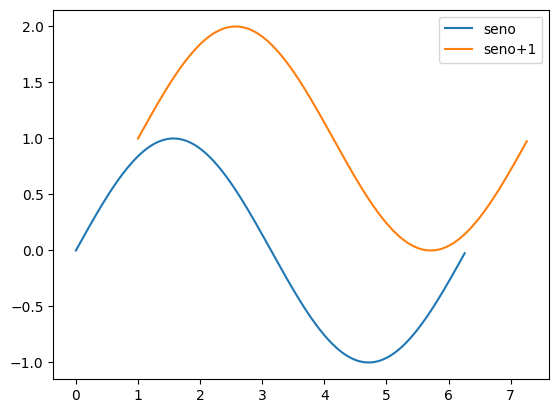

In [9]:
# legenda

plt.plot(df['x'],df['y'],label='seno')
plt.plot(df['x2'],df['y2'],label='seno+1')
plt.legend(loc='best')
plt.show()

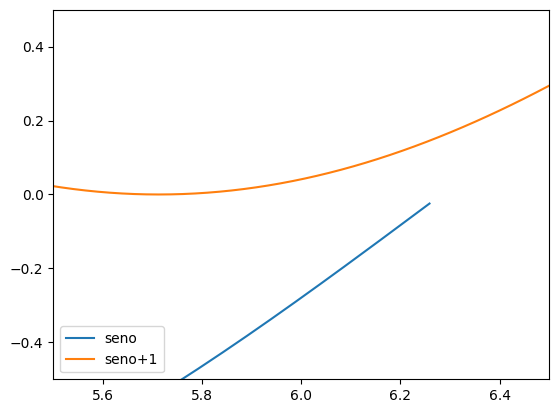

In [10]:
# zoom su assi

plt.xlim(5.5,6.5)
plt.ylim(-0.5,0.5)
plt.plot(df['x'],df['y'],label='seno')
plt.plot(df['x2'],df['y2'],label='seno+1')
plt.legend(loc='lower left')
plt.show()


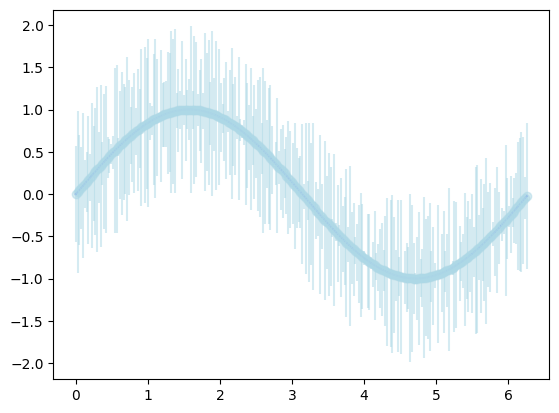

In [14]:
# barre di errore

df['yerr'] = np.random.rand(256)
plt.plot(df['x'],df['y'], c='blue')
plt.errorbar(df['x'],df['y'],yerr = df['yerr'], c='lightblue', fmt='o', alpha=0.5)
plt.show()

# Scatter plot

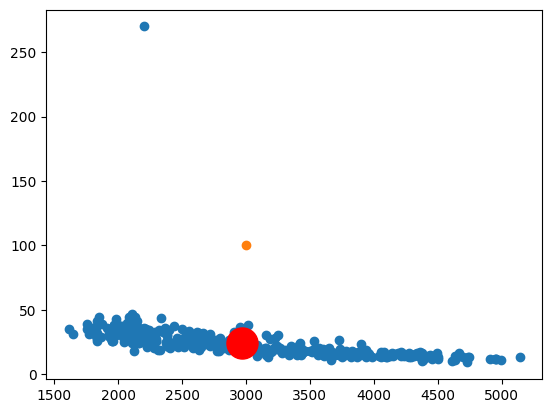

In [16]:
df = pd.read_csv('../../dataset/autoMpg.csv')

#df.loc[df['mpg'] == 270.0,'mpg'] = 27.0

plt.scatter(df['weight'],df['mpg'])
plt.scatter(3000,100)
plt.scatter(df['weight'].mean(),df['mpg'].mean(),c='#ff0000',s=500)
plt.show()

# Boxplot

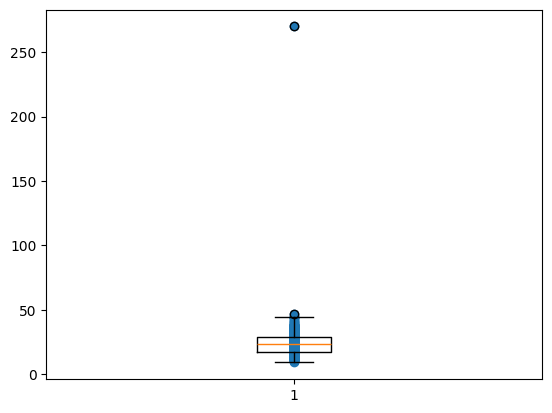

In [20]:
plt.boxplot(df['mpg'])
plt.scatter([1 for x in range(len(df['mpg']))], df['mpg'])
plt.show()

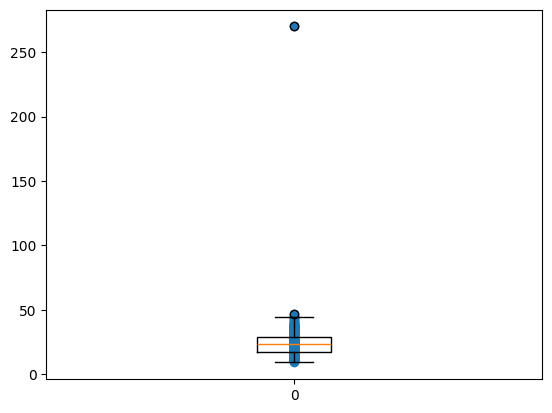

In [21]:
#combina grafici

plt.scatter([0]*df.shape[0],df['mpg'])
plt.boxplot(df['mpg'],positions=[0])
plt.show()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cylinders     398 non-null    int64  
 1   displacement  398 non-null    float64
 2   horsepower    398 non-null    object 
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model         398 non-null    int64  
 6   origin        398 non-null    int64  
 7   mpg           398 non-null    float64
dtypes: float64(3), int64(4), object(1)
memory usage: 25.0+ KB


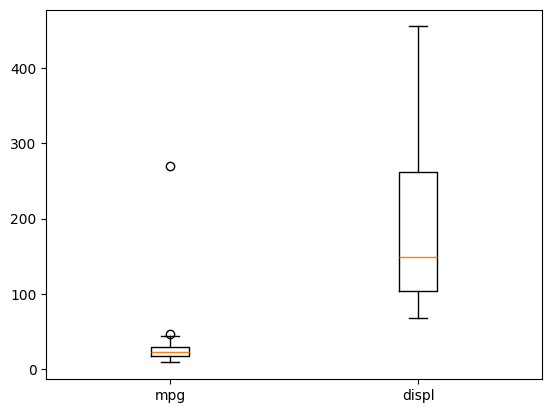

In [22]:
# multiple boxplot

plt.boxplot([df['mpg'],df['displacement']])
plt.xticks([1,2],['mpg','displ'])
plt.show()


# Grafici a barre

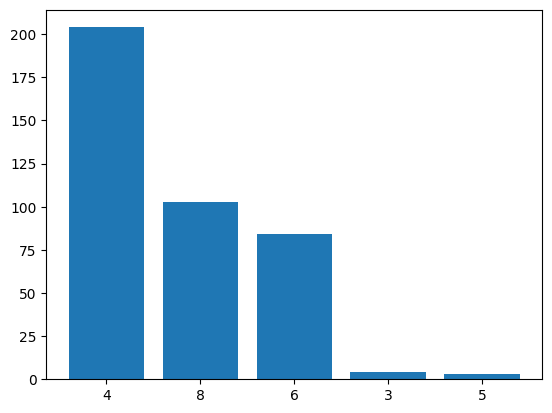

In [28]:
cc = df['cylinders'].value_counts()
plt.xticks(range(len(cc)),cc.index)
plt.bar(range(len(cc)),cc)
plt.show()

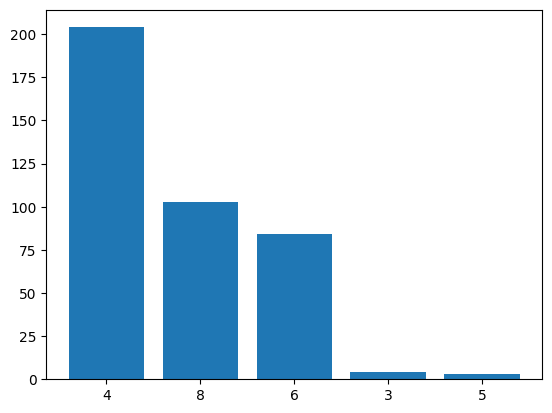

In [36]:
cc = df['cylinders'].value_counts().to_frame().reset_index()
plt.xticks(range(len(cc)),cc['cylinders'])
plt.bar(range(len(cc)),cc['count'])
plt.show()


# Grafici Multipli

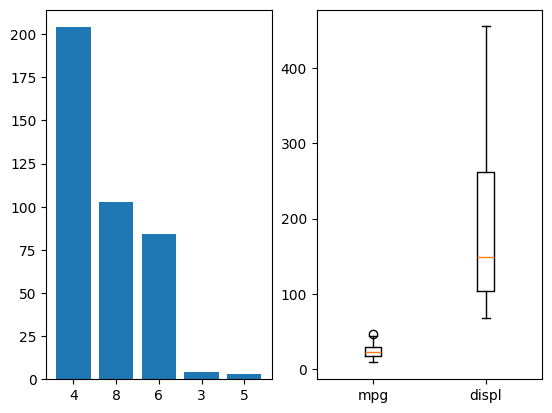

In [17]:
plt.subplot(1,2,1)

cc = df['cylinders'].value_counts()
plt.xticks(range(len(cc)),cc.index)
plt.bar(range(len(cc)),cc)

plt.subplot(1,2,2)

plt.boxplot([df['mpg'],df['displacement']])
plt.xticks([1,2],['mpg','displ'])

plt.show()

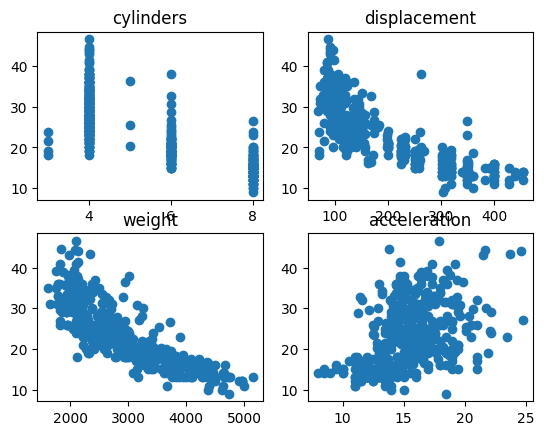

In [18]:
# esempio, 4 scatter disposti in una griglia 2 * 2.
# i grafici confrontano  cylinders, displacemnts, weight, acceleration 
# con mpg
f1 = plt.subplot(2,2,1)
f1.title.set_text('cylinders')
plt.scatter(df['cylinders'],df['mpg'])
f2 = plt.subplot(2,2,2)
f2.title.set_text('displacement')
plt.scatter(df['displacement'],df['mpg'])
f3 = plt.subplot(2,2,3)
f3.title.set_text('weight')
plt.scatter(df['weight'],df['mpg'])
f4= plt.subplot(2,2,4)
f4.title.set_text('acceleration')
plt.scatter(df['acceleration'],df['mpg'])

plt.show()
